# 01 — Exploratory Data Analysis

Goal: understand the raw dataset before any modelling.

- Data shape, types, missing values
- Class distribution (fraud vs normal)
- Feature distributions and correlations
- Key insights to guide preprocessing decisions

In [11]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Data

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


284,807 transactions across 31 columns: `Time`, `Amount`, `V1–V28` (PCA-anonymised features), and `Class` (the label) — `Time` and `Amount` are raw and will need scaling, while `V1–V28` are already PCA-transformed and can be used as-is.


## 2. Basic Info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicates: 1081


In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**What we found:** Zero missing values, but **1,081 duplicate rows** — rows that are identical across all 31 columns including all V1–V28 PCA features.

**Impact:** No imputation is needed. However, deduplication is required. Because PCA features encode the full transaction fingerprint, two rows that are identical across all 28 PCA components cannot realistically be two different real transactions — they are data recording artifacts and should be dropped. Note that 32 of the duplicated rows are fraud (`Class=1`), so deduplication slightly reduces the available fraud training examples, but keeping artificial copies would inflate model metrics falsely.'

## 3. Class Distribution

Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


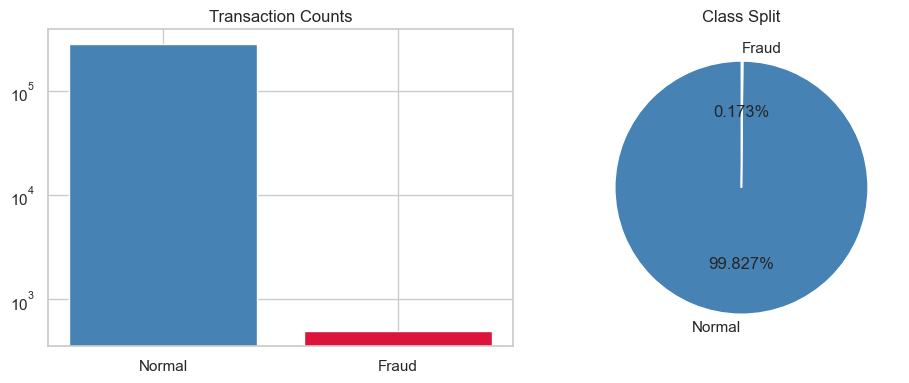

In [6]:
counts = df['Class'].value_counts()
print(counts)
print(f'\nFraud rate: {counts[1] / len(df) * 100:.4f}%')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Normal', 'Fraud'], counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Transaction Counts')
axes[0].set_yscale('log')

axes[1].pie(counts.values, labels=['Normal', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'crimson'], startangle=90)
axes[1].set_title('Class Split')
plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png', dpi=150)
plt.show()

- Fraud detection is a binary classification task, so we need to know how balanced the two classes are before choosing a model or evaluation metric.

- Only 492 out of 284,807 transactions are fraudulent — just **0.17%**. A model that blindly predicts "normal" every time would score 99.83% accuracy while catching zero fraud.

- Accuracy is useless here. We will use **Precision, Recall, F1, and AUC-PR** as evaluation metrics. We will also apply **SMOTE oversampling** during preprocessing to give the model enough fraud examples to learn from.


## 4. Transaction Amount

/var/folders/ng/7_90m6m117g6f86x83b1k8sc0000gn/T/ipykernel_33072/4215733535.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([normal_amt, fraud_amt], labels=['Normal', 'Fraud'],


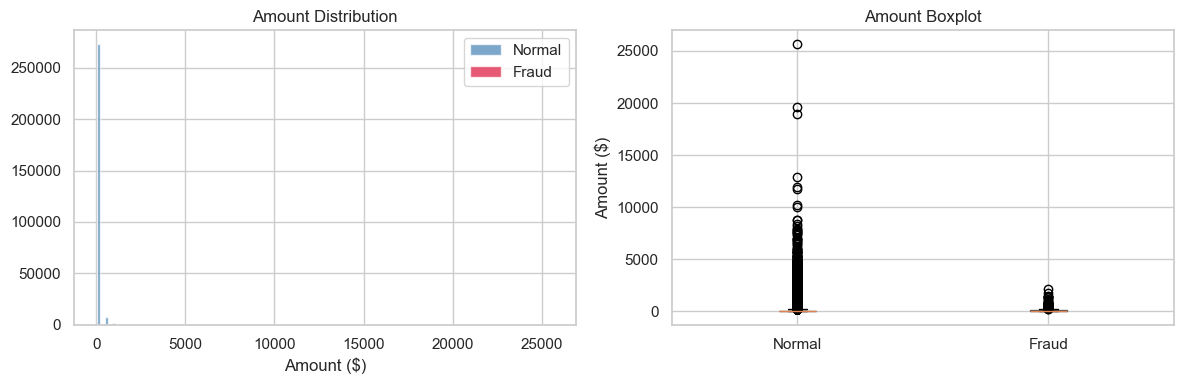

Normal  — mean: $88.29, median: $22.00
Fraud   — mean: $122.21, median: $9.25


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

normal_amt = df[df['Class'] == 0]['Amount']
fraud_amt  = df[df['Class'] == 1]['Amount']

axes[0].hist([normal_amt, fraud_amt], bins=60, alpha=0.7,
             label=['Normal', 'Fraud'], color=['steelblue', 'crimson'])
axes[0].set_xlabel('Amount ($)')
axes[0].set_title('Amount Distribution')
axes[0].legend()

axes[1].boxplot([normal_amt, fraud_amt], labels=['Normal', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Amount Boxplot')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.savefig('../reports/figures/amount_distribution.png', dpi=150)
plt.show()

print(f'Normal  — mean: ${normal_amt.mean():.2f}, median: ${normal_amt.median():.2f}')
print(f'Fraud   — mean: ${fraud_amt.mean():.2f}, median: ${fraud_amt.median():.2f}')

- Fraud often has a distinct spending pattern — scammers may prefer small inconspicuous charges or, conversely, large one-off withdrawals. Visualising the amount distribution by class helps us check this.

- Normal transactions span a wide range up to ~$25,000. Fraudulent transactions are clustered at **lower amounts** (median ~$9 vs ~$22 for normal), suggesting fraudsters tend to make smaller, less noticeable charges.

- `Amount` carries predictive signal and must be kept as a feature. Because its scale is very different from the PCA features, it needs **standard scaling** in preprocessing before being fed into any distance- or gradient-sensitive model.


## 5. Feature Correlations with Fraud

Top 15 features correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
V1     0.101347
V9     0.097733
V5     0.094974
V2     0.091289
V6     0.043643
Name: Class, dtype: float64


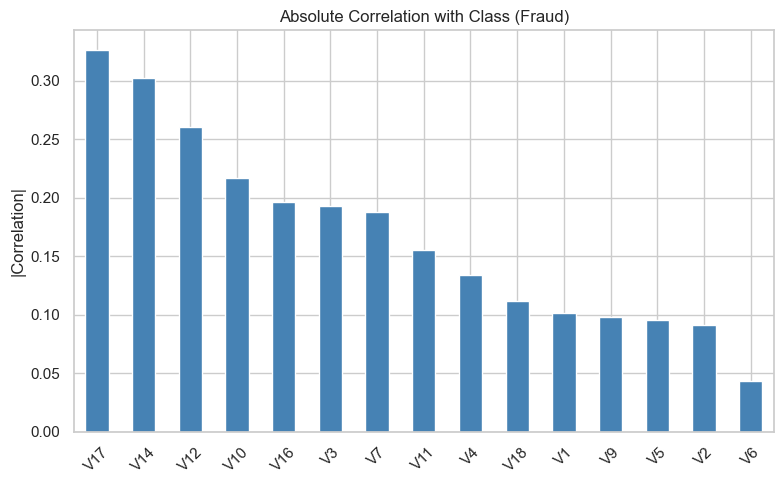

In [8]:
corr_with_class = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
print('Top 15 features correlated with fraud:')
print(corr_with_class.head(15))

plt.figure(figsize=(8, 5))
corr_with_class.head(15).plot(kind='bar', color='steelblue')
plt.title('Absolute Correlation with Class (Fraud)')
plt.ylabel('|Correlation|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/feature_correlations.png', dpi=150)
plt.show()

- With 28 anonymised PCA features, we need a way to rank which ones are most likely to help the model distinguish fraud from normal — rather than treating all features as equally important.

- `V14`, `V17`, `V12`, and `V10` have the strongest absolute correlation with `Class`. Several features (e.g. `V13`, `V15`) have near-zero correlation and may add noise.

- High-correlation features are strong candidates for the model to rely on. If we later need to reduce dimensionality or interpret model decisions, these top features are the starting point. Low-correlation features may be dropped in a feature selection step.


## 5.5 Feature Distributions by Class (V1–V28)

Visualise how each PCA feature distributes differently for fraud vs normal transactions.
Features where the two distributions clearly separate (e.g. V14, V12, V10) are strong predictors.
Features where distributions heavily overlap carry little discriminative power and are candidates for removal.

/var/folders/ng/7_90m6m117g6f86x83b1k8sc0000gn/T/ipykernel_33072/330209167.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


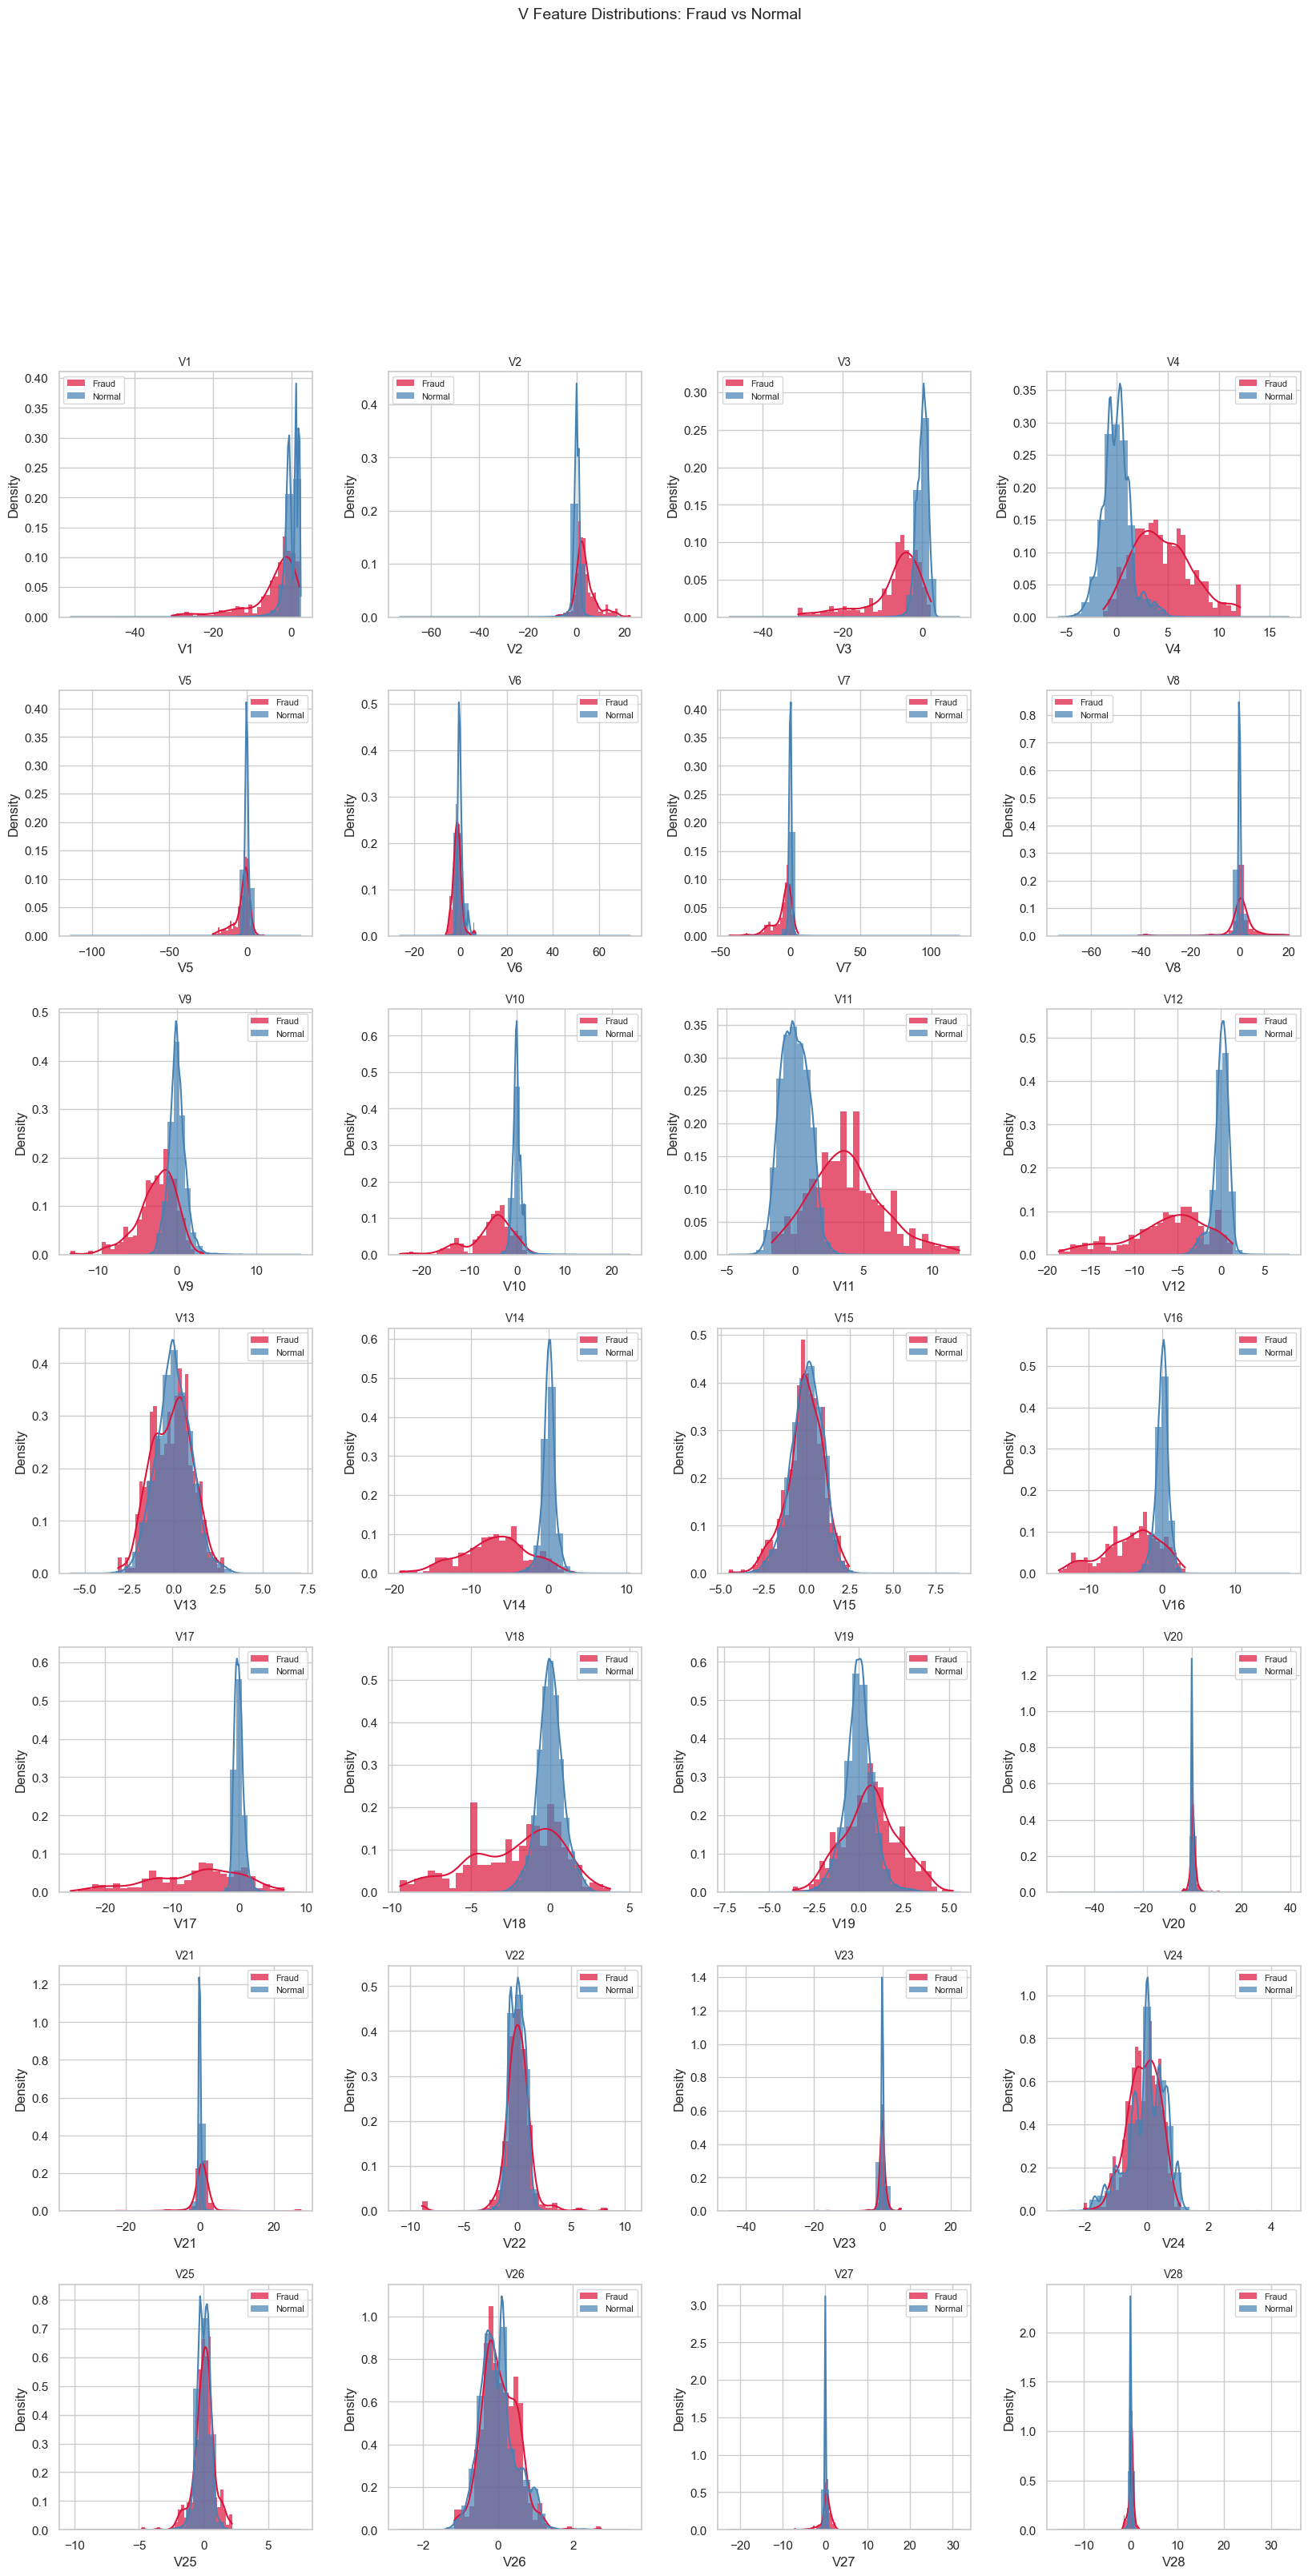

In [12]:
v_features = df.iloc[:, 1:29].columns
plt.figure(figsize=(20, 35))
gs = gridspec.GridSpec(7, 4, hspace=0.3, wspace=0.3)

for i, cn in enumerate(v_features):
    ax = plt.subplot(gs[i // 4, i % 4])
    sns.histplot(df[df['Class'] == 1][cn], bins=30, label='Fraud',
                 alpha=0.7, kde=True, stat='density', edgecolor='none', color='crimson')
    sns.histplot(df[df['Class'] == 0][cn], bins=30, label='Normal',
                 alpha=0.7, kde=True, stat='density', edgecolor='none', color='steelblue')
    ax.set_title(cn, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('V Feature Distributions: Fraud vs Normal', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

Features with clearly separated distributions (V4, V10, V11, V12, V14, V17) align with the high-correlation ranking from Section 5. Features like V13, V15, V22–V28 show near-identical distributions between classes —
these carry minimal discriminative signal and will be dropped in preprocessing.

## 6. Correlation Heatmap (top features)

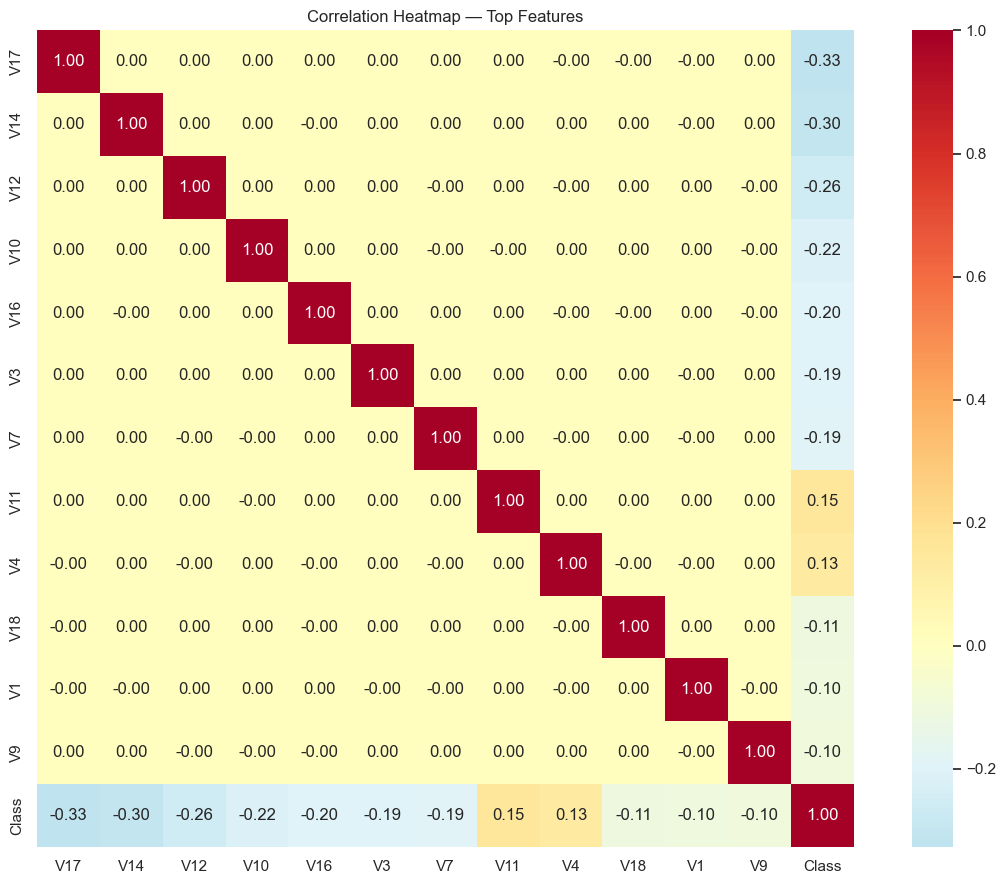

In [9]:
top_features = corr_with_class.head(12).index.tolist() + ['Class']
plt.figure(figsize=(12, 9))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, square=True)
plt.title('Correlation Heatmap — Top Features')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150)
plt.show()

- Even if individual features correlate with fraud, some features may be strongly correlated with *each other* — which can cause multicollinearity and make linear models unstable or redundant.

- The top PCA features are largely **independent of each other** (low inter-feature correlation), which is expected since PCA by design produces orthogonal components.

- We can use all top features without worrying about multicollinearity. Tree-based models (like Random Forest or XGBoost) are unaffected anyway, but this also confirms that a logistic regression baseline will be stable.


## 7. Key Takeaways

- **Class imbalance**: fraud is ~0.17% of transactions — accuracy is a misleading metric; use Precision, Recall, F1, AUC-PR instead.
- **No missing values**: dataset is clean, no imputation needed.
- **V features**: already PCA-transformed (anonymised), no further encoding needed.
- **Amount & Time**: not PCA-transformed — need scaling in preprocessing.
- **Next step**: `02_preprocessing.ipynb` — clean data, engineer features, and scale for modelling.